# EXHALE steady-state (JFNK) solver — results

Companion to `docs/steady_solver_memo.pdf` and `docs/steady_solver_design.md`.
All data are read from the run directories under `regression/` (execute this
notebook from `regression/`). Solver recipe per run:
`ATES_PTC=1 ATES_PTC_JFNK=1 ATES_PTC_DTAU0=1.0` with input lines
`Valve eps:` and `Resid tol:` (or the wired `Solver: Newton`).

Key claims shown below:
1. **WASP-121b**: the Newton solution sits on the marching asymptote
   ($\log_{10}\dot M\simeq13.71$), is the flattest state produced, and costs
   $\sim$1/200 of the (insufficient) 35k-step marching.
2. **HD189733b**: Newton converges in 33 s where marching spent $>$3 h
   (1.16M steps) without converging; the converged $\dot M$ is $\sim$0.08 dex
   above the still-drifting marching estimates (same premature pattern).
3. **Valve-$\varepsilon$ insensitivity**: $\varepsilon_v=10^{-4}$ vs $10^{-5}$
   give identical answers (4 decimals).
4. JFNK iteration histories, including the HD189 practical floor.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import re, os

MU, RJ = 1.673e-24, 7.1492e9

def load_hydro(path):
    h = np.loadtxt(path)
    return dict(r=h[:,0], n=h[:,1], v=h[:,2], p=h[:,3], T=h[:,4])

def mdot_raw(d, Rp_cm):
    return 4*np.pi*d['n']*MU*d['v']*(d['r']*Rp_cm)**2

def spread(d, Rp_cm, rmin):
    F = mdot_raw(d, Rp_cm); m = (d['r'] >= rmin) & (d['v'] > 0)
    return (F[m].max()-F[m].min())/F[m].min()

def jfnk_history(logfile):
    it, rn, fs, lam = [], [], [], []
    pat = re.compile(r'\(JFNK\) it\s*(\d+)\s+\|\|R\|\|=\s*([0-9.E+-]+)'
                     r'\s+\|\|Fs?\|\|2=\s*([0-9.E+-]+).*lam=\s*([0-9.E+-]+)')
    for line in open(logfile, errors='ignore'):
        m = pat.search(line)
        if m:
            it.append(int(m.group(1))); rn.append(float(m.group(2)))
            fs.append(float(m.group(3))); lam.append(float(m.group(4)))
    return np.array(it), np.array(rn), np.array(fs), np.array(lam)

WASP = dict(Rp=2.2075*RJ, runs={
    'Newton (22 its, tol 1e-4)': 'valve_sens/eps4/Hydro_ioniz.txt',
    'marching 35k steps'       : 'crit_cold/output/Hydro_ioniz.txt',
    'old golden (premature)'   : 'golden/wasp_full/Hydro_ioniz.txt'})
HD189 = dict(Rp=1.193*RJ, runs={
    'Newton (129 its, 33 s)'      : 'jfnk_hd189/output/Hydro_ioniz.txt',
    'marching 1.16M steps'        : '../../phase_minus1_HD189/A_nostall/output/Hydro_ioniz.txt',
    'pristine ATES-Code-main'     : '../../phase_minus1_HD189/main_run/output/Hydro_ioniz.txt'})
CLR = ['C2','C0','C1']

## 1. Summary tables

In [2]:
for name, cfg, rmin in [('WASP-121b', WASP, 1.5), ('HD189733b', HD189, 2.0)]:
    print(f'=== {name} ===')
    for tag, f in cfg['runs'].items():
        d = load_hydro(f); F = mdot_raw(d, cfg['Rp'])
        print(f"  {tag:28s} log10 Mdot = {np.log10(F[-5]):7.4f}   "
              f"spread(r>={rmin}) = {spread(d,cfg['Rp'],rmin):.2e}   "
              f"T_max = {d['T'].max():7,.0f} K")
    print()

=== WASP-121b ===
  Newton (22 its, tol 1e-4)    log10 Mdot = 13.7110   spread(r>=1.5) = 5.05e-04   T_max =  10,750 K
  marching 35k steps           log10 Mdot = 13.7066   spread(r>=1.5) = 1.17e-03   T_max =  10,767 K
  old golden (premature)       log10 Mdot = 13.6309   spread(r>=1.5) = 1.78e-03   T_max =  11,021 K

=== HD189733b ===
  Newton (129 its, 33 s)       log10 Mdot = 10.2984   spread(r>=2.0) = 7.59e-03   T_max =  11,038 K
  marching 1.16M steps         log10 Mdot = 10.2179   spread(r>=2.0) = 1.25e-02   T_max =  11,126 K
  pristine ATES-Code-main      log10 Mdot = 10.2228   spread(r>=2.0) = 1.21e-02   T_max =  11,121 K



## 2. Profiles — Newton vs marching

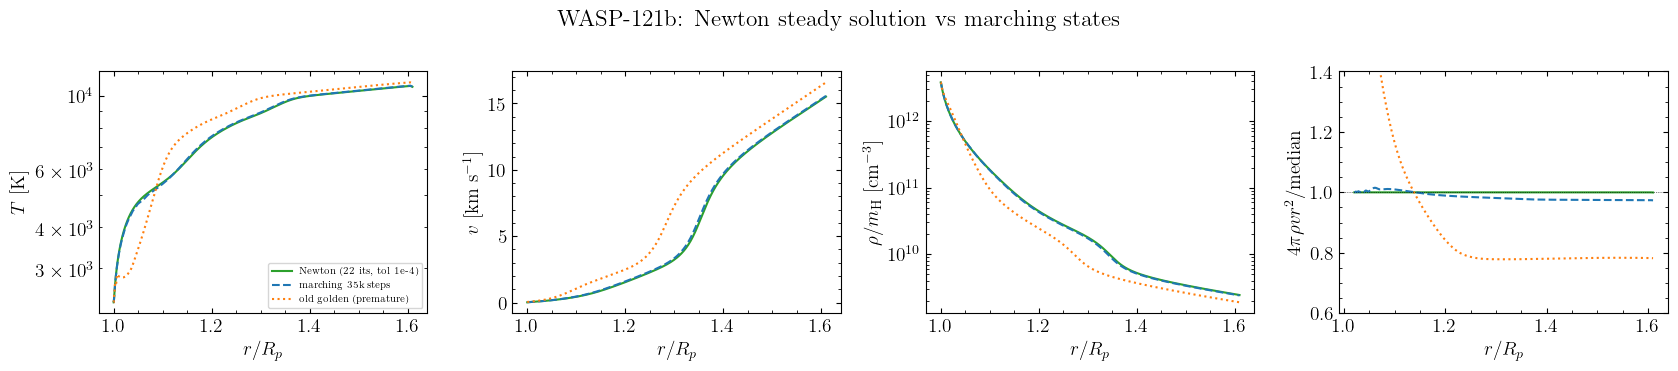

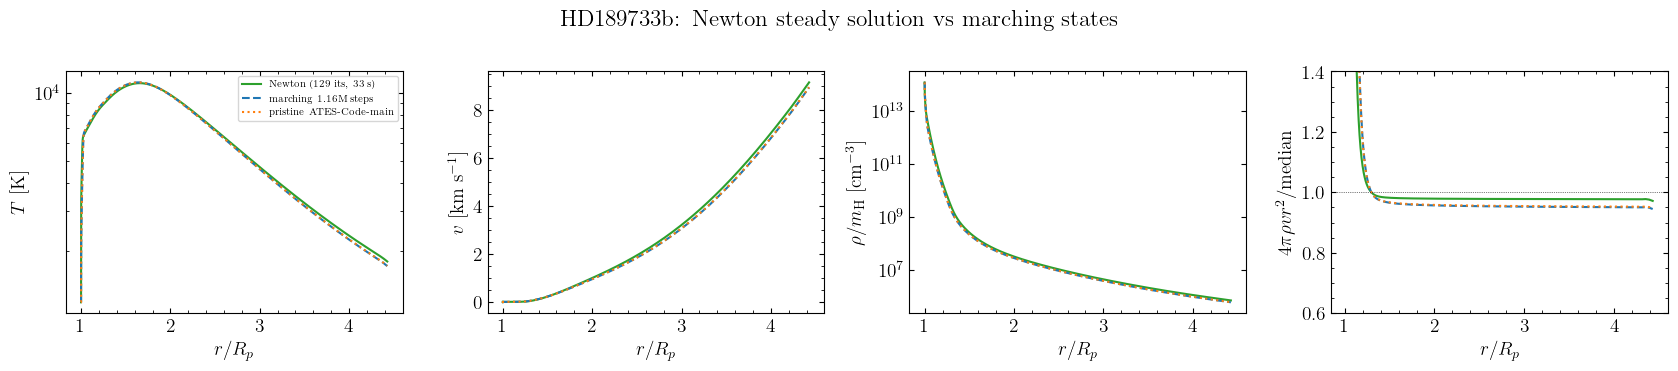

In [3]:
for name, cfg, rmin in [('WASP-121b', WASP, 1.5), ('HD189733b', HD189, 2.0)]:
    fig, axes = plt.subplots(1, 4, figsize=(17, 3.8))
    for (tag, f), c in zip(cfg['runs'].items(), CLR):
        d = load_hydro(f)
        ls = '-' if 'Newton' in tag else ('--' if 'march' in tag else ':')
        axes[0].semilogy(d['r'], d['T'], c, ls=ls, label=tag)
        axes[1].plot(d['r'], d['v']/1e5, c, ls=ls)
        axes[2].semilogy(d['r'], d['n'], c, ls=ls)
        F = mdot_raw(d, cfg['Rp']); m = (d['r'] >= 1.02) & (d['v'] > 0)
        axes[3].plot(d['r'][m], F[m]/np.median(F[m]), c, ls=ls)
    axes[0].set_ylabel(r'$T$ [K]'); axes[0].legend(fontsize=7)
    axes[1].set_ylabel(r'$v$ [km s$^{-1}$]')
    axes[2].set_ylabel(r'$\rho/m_{\rm H}$ [cm$^{-3}$]')
    axes[3].set_ylabel(r'$4\pi\rho v r^2$/median'); axes[3].set_ylim(0.6, 1.4)
    axes[3].axhline(1, color='k', lw=0.5, ls=':')
    for ax in axes: ax.set_xlabel(r'$r/R_p$')
    fig.suptitle(f'{name}: Newton steady solution vs marching states')
    fig.tight_layout()

The right-hand panels are the steady-state diagnostic: the Newton solutions
(solid green) are the flattest $4\pi\rho v r^2$ profiles in both planets.
For HD189733b note the still-drifting marching states sit visibly LOWER in
flux level — the same premature-snapshot pattern quantified for WASP-121b.

## 3. JFNK iteration histories

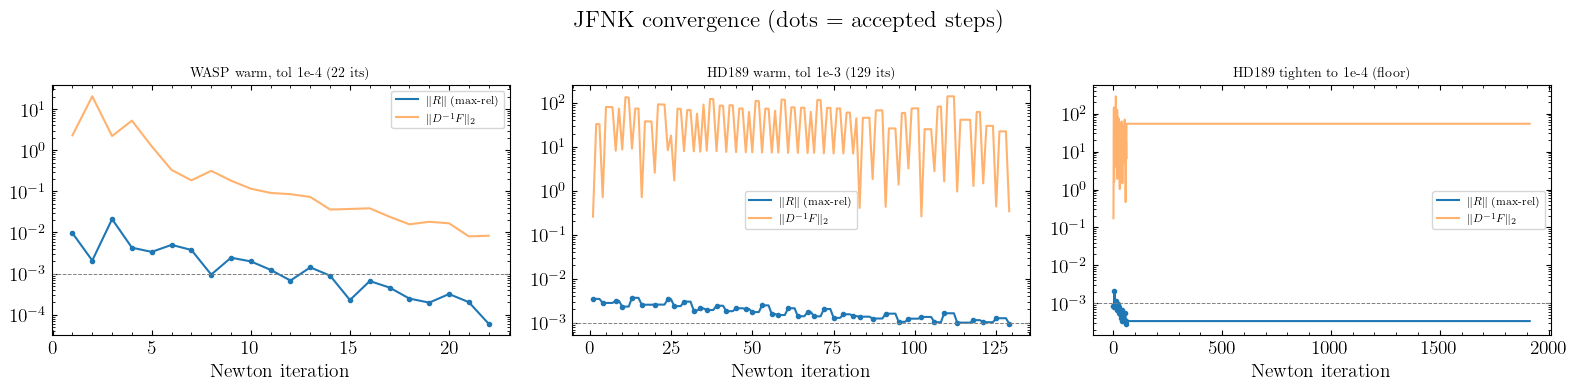

In [4]:
logs = [('WASP warm, tol 1e-4 (22 its)',  'ptc_warm/tight.log'),
        ('HD189 warm, tol 1e-3 (129 its)','jfnk_hd189/run.log'),
        ('HD189 tighten to 1e-4 (floor)', 'jfnk_hd189_tight/run.log')]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (tag, lf) in zip(axes, logs):
    if not os.path.exists(lf):
        ax.set_title(tag + ' (missing)'); continue
    it, rn, fs, lam = jfnk_history(lf)
    ax.semilogy(it, rn, 'C0', label=r'$\|R\|$ (max-rel)')
    ax.semilogy(it, fs, 'C1', alpha=0.6, label=r'$\|D^{-1}F\|_2$')
    acc = lam > 1e-3
    ax.semilogy(it[acc], rn[acc], 'C0o', ms=3)
    ax.axhline(1e-3, color='gray', ls='--', lw=0.7)
    ax.set_xlabel('Newton iteration'); ax.set_title(tag, fontsize=10)
    ax.legend(fontsize=8)
fig.suptitle('JFNK convergence (dots = accepted steps)')
fig.tight_layout()

WASP converges smoothly (every step accepted at $\lambda=1$). HD189733b is
*bumpy*: the frozen-WENO-weight refresh at each outer iterate jumps the merit
(the breathing base makes the weights very sensitive), and the non-monotone
line search grinds through; below $\|R\|\sim3\times10^{-4}$ progress stalls —
the practical floor of the current settings for this planet.

## 4. Valve-$\varepsilon$ sensitivity ($10^{-4}$ vs $10^{-5}$)

eps=1e-4: log10 Mdot = 13.7110, T_max = 10750.2 K
eps=1e-5: log10 Mdot = 13.7110, T_max = 10750.2 K


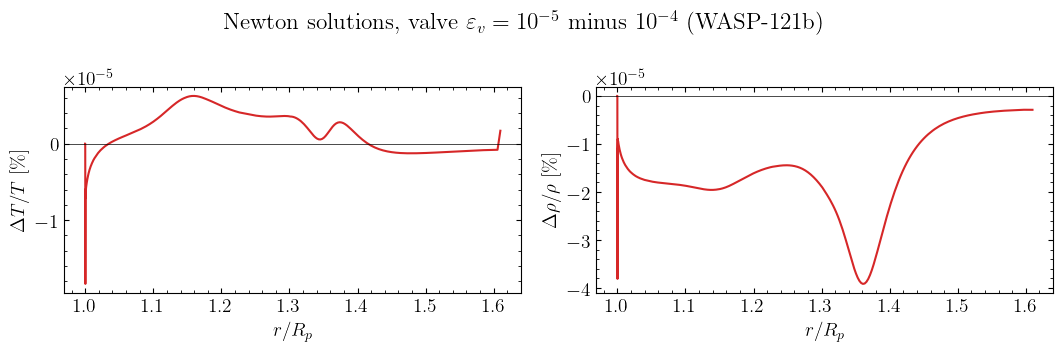

In [5]:
d4 = load_hydro('valve_sens/eps4/Hydro_ioniz.txt')
d5 = load_hydro('valve_sens/eps5/output/Hydro_ioniz.txt')
F4, F5 = mdot_raw(d4, WASP['Rp']), mdot_raw(d5, WASP['Rp'])
print(f'eps=1e-4: log10 Mdot = {np.log10(F4[-5]):.4f}, T_max = {d4["T"].max():.1f} K')
print(f'eps=1e-5: log10 Mdot = {np.log10(F5[-5]):.4f}, T_max = {d5["T"].max():.1f} K')
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(d4['r'], 100*(d5['T']-d4['T'])/d4['T'], 'C3')
axes[0].set_ylabel(r'$\Delta T/T$ [\%]')
axes[1].plot(d4['r'], 100*(d5['n']-d4['n'])/np.maximum(d4['n'],1e-30), 'C3')
axes[1].set_ylabel(r'$\Delta \rho/\rho$ [\%]')
for ax in axes: ax.set_xlabel(r'$r/R_p$'); ax.axhline(0, color='k', lw=0.5)
fig.suptitle(r'Newton solutions, valve $\varepsilon_v = 10^{-5}$ minus $10^{-4}$ (WASP-121b)')
fig.tight_layout()

## 5. End-to-end `Solver: Newton` (cold start)

In [6]:
lf = 'solver_newton_cold/run.log'
if os.path.exists(lf):
    txt = open(lf, errors='ignore').read()
    for pat in ('switched PLM -> WENO3', 'Newton finish', 'JFNK) done', 'Mdot'):
        for line in txt.splitlines():
            if pat in line: print(line.strip())
    if os.path.exists('solver_newton_cold/output/Hydro_ioniz.txt'):
        d = load_hydro('solver_newton_cold/output/Hydro_ioniz.txt')
        F = mdot_raw(d, WASP['Rp'])
        print(f'\nfinal: log10 Mdot = {np.log10(F[-5]):.4f}, '
              f'spread(r>=1.5) = {spread(d, WASP["Rp"], 1.5):.2e}, '
              f'T_max = {d["T"].max():.0f} K')
else:
    print('run not available yet')

-> switched PLM -> WENO3 at du =  3.7027E-01, step 1
(EXHALE_main) Newton finish at step 27000, target ||R|| <  1.00E-03
(JFNK) done info=0 ||R||=  5.421E-04
---> 2D approximate method: Rate/2 + Mdot/2
---> Log10 of steady-state Mdot = 13.39 g/s

final: log10 Mdot = 13.7111, spread(r>=1.5) = 5.05e-04, T_max = 10748 K


## 6. Absorption (transmission) spectra of the Newton solutions

`EXHALE_transit.py` post-processes each converged Newton solution (after a PP-only run
generates the `*_adv.txt` profiles): He I 10830 triplet, Ly$\alpha$,
H$\alpha$, H$\beta$, plus the Phase-5 metal resonance lines (Mg II 2796,
Ca II K, Na I D2 — WASP-121b, metals on). Per-planet stellar parameters:
WASP-121b $R_*=1.458R_\odot$, $T_*=6459$ K, $P_{\rm rot}=1.275$ d;
HD189733b $R_*=0.765R_\odot$, $T_*=4875$ K, $P_{\rm rot}=2.218$ d.
Run directories: `tpm_wasp/`, `tpm_hd189/`.

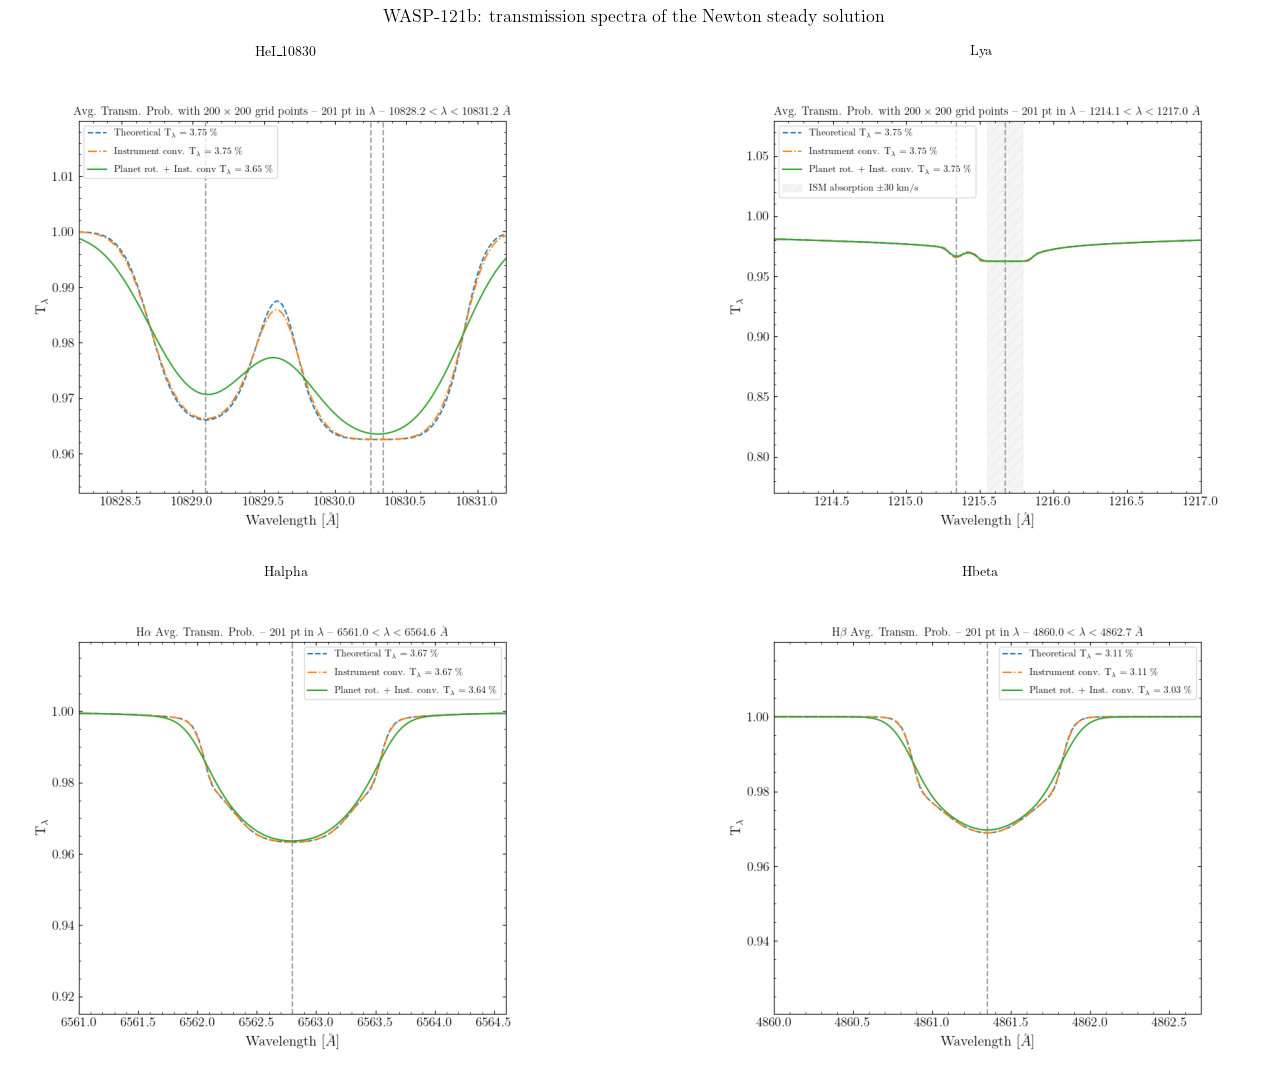

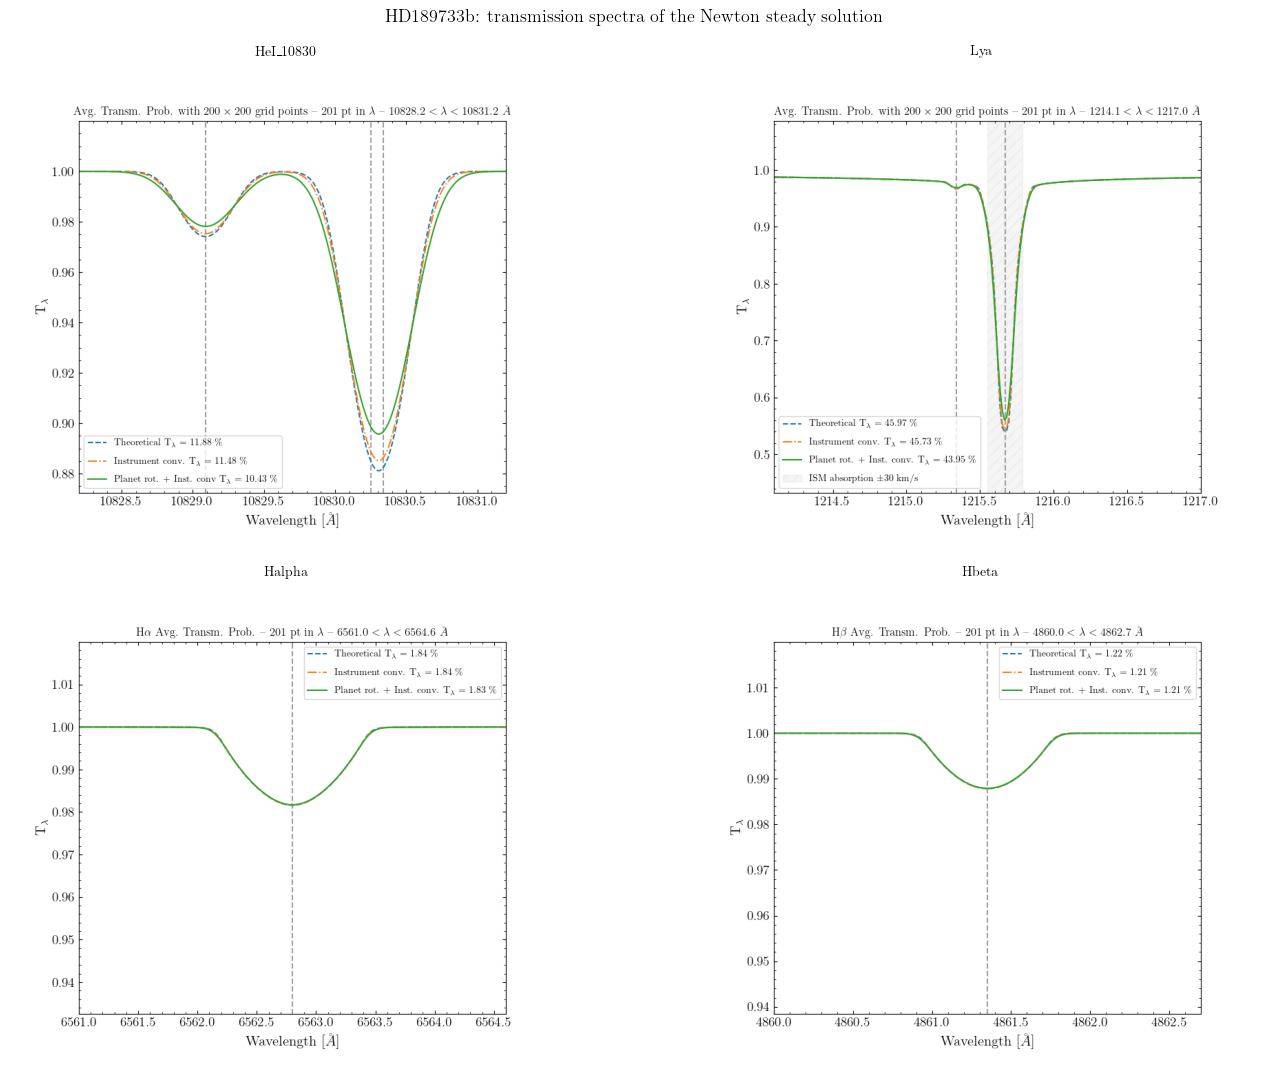

In [7]:
import matplotlib.image as mpimg
specs = ['HeI_10830.png', 'Lya.png', 'Halpha.png', 'Hbeta.png']
for planet, d in [('WASP-121b', 'tpm_wasp'), ('HD189733b', 'tpm_hd189')]:
    fig, axes = plt.subplots(2, 2, figsize=(15, 11))
    for ax, f in zip(axes.flat, specs):
        p = os.path.join(d, f)
        if os.path.exists(p):
            ax.imshow(mpimg.imread(p)); ax.axis('off')
            ax.set_title(f.replace('.png',''), fontsize=10)
        else:
            ax.text(0.5, 0.5, f+' missing', ha='center'); ax.axis('off')
    fig.suptitle(f'{planet}: transmission spectra of the Newton steady solution',
                 fontsize=13)
    fig.tight_layout()

In [8]:
print('Peak excess absorption (theoretical), from TPM logs:')
for planet, d in [('WASP-121b','tpm_wasp'), ('HD189733b','tpm_hd189')]:
    txt = open(os.path.join(d,'tpm.log'), errors='ignore').read().splitlines()
    print(f'--- {planet} ---')
    for i, line in enumerate(txt):
        if 'Transmission probability at peak' in line:
            tag = line.split('peak')[-1].strip(' -')
            for nxt in txt[i+1:i+4]:
                if 'Theoretical' in nxt:
                    print(f'  {tag:28s} {float(nxt.split(":")[-1].replace("%","")):6.2f} %')
                    break
        if '(TPM)' in line and any(s in line for s in ('Mg II','Ca II','Na I')):
            print(f'  {line.strip()}')

Peak excess absorption (theoretical), from TPM logs:
--- WASP-121b ---
  (TPM)   Mg II 2796           3.719           0.386
  (TPM)   Ca II K 3934         3.751           0.262
  (TPM)   Na I D2 5890         1.651           0.078
  metastable HeI triplet         3.75 %
  HI Lya                         3.75 %
  HI H-alpha                     3.67 %
  HI H-beta                      3.11 %
--- HD189733b ---
  (TPM)   Mg II 2796          -0.000          -0.000
  (TPM)   Ca II K 3934        -0.000          -0.000
  (TPM)   Na I D2 5890        -0.000          -0.000
  metastable HeI triplet        11.88 %
  HI Lya                        45.97 %
  HI H-alpha                     1.84 %
  HI H-beta                      1.22 %


## Notes

- All solver features are opt-in; the marching default is byte-identical
  (regression-gated after every change).
- Interpretations are tentative where marching references were still
  drifting; the Newton states are the best-converged states available
  (smallest criterion-independent residual $\|R\|$).